# Package Import

In [1]:
from pathlib import Path 
# from os import makedirs
import sys
import importlib
import re

import pandas as pd
import numpy as np

In [2]:
PYTHON_HELPER_FOLDER = Path(r"R:\Bleidistel_Niko\COMSOL\COMSOL Python Helpers\COMSOL Python Helpers Version 1.0\py-helpers")

# Add the path to the custom packages to sys.path so that they can be imported
sys.path.append(str(PYTHON_HELPER_FOLDER.resolve()))

# import custom packages
import plot_functions as pfs

# reload custom packages to reflect recent changes
_ = importlib.reload(pfs)

# Configuration

In [3]:
INPUT_FOLDER = Path(r"R:\Bleidistel_Niko\COMSOL\COMSOL Script Outputs\000_New_Output")
OUTPUT_FOLDER = INPUT_FOLDER
LOG_FILE = INPUT_FOLDER / "time_log.csv"

# Import

In [4]:
df_time_log = pd.read_csv(LOG_FILE, sep=";")
df_time_log["Timestamp"] = pd.to_datetime(df_time_log["Timestamp"])
display(df_time_log.head())

,Timestamp,Log-Level,Message,Since Start (s),Since Start (H:M:S.ms),Since Last Log (s),Since Last Log (H:M:S.ms)
0,2026-07-03 13:37:53,INFO,Started running Python script,0.0001,00:00:00.000,0.0001,00:00:00.000
1,2026-07-03 13:37:53,INFO,Starting plotting all available txts,0.2860,00:00:00.285,0.2859,00:00:00.285
2,2026-07-03 13:37:53,INFO,Started plotting workflow for sweep results in...,0.2877,00:00:00.287,0.0017,00:00:00.001
3,2026-07-03 13:38:11,INFO,Imported data from 01_planar_waveguide_mf_expo...,17.7494,00:00:17.749,17.4618,00:00:17.461
4,2026-07-03 13:38:29,INFO,Masked and interpolated depth data for 01_plan...,35.7276,00:00:35.727,17.9782,00:00:17.978


# Pull Info

In [5]:
SWEEP_FOLDER = INPUT_FOLDER / "Sweep_Data"

# get all iteration folders in the sweep folder
iteration_folders = [f.name for f in SWEEP_FOLDER.iterdir() if f.is_dir()]
iteration_folders = sorted(iteration_folders, key=lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(s))])
print(iteration_folders)

['Iteration 0 (epilayer_xz_mesh_scale 5.0)', 'Iteration 1 (epilayer_xz_mesh_scale 6.0)', 'Iteration 2 (epilayer_xz_mesh_scale 7.0)', 'Iteration 3 (epilayer_xz_mesh_scale 8.0)', 'Iteration 4 (epilayer_xz_mesh_scale 9.0)', 'Iteration 5 (epilayer_xz_mesh_scale 10.0)', 'Iteration 6 (epilayer_xz_mesh_scale 11.0)', 'Iteration 7 (epilayer_xz_mesh_scale 12.0)', 'Iteration 8 (epilayer_xz_mesh_scale 13.0)', 'Iteration 9 (epilayer_xz_mesh_scale 14.0)', 'Iteration 10 (epilayer_xz_mesh_scale 15.0)', 'Iteration 11 (epilayer_xz_mesh_scale 16.0)', 'Iteration 12 (epilayer_xz_mesh_scale 17.0)', 'Iteration 13 (epilayer_xz_mesh_scale 18.0)', 'Iteration 14 (epilayer_xz_mesh_scale 19.0)']


# Time Calculation

In [6]:
# get start and end timestamps for each study
starts = df_time_log[df_time_log["Message"].str.contains("Running study")].reset_index(drop=True)
ends = df_time_log[df_time_log["Message"].str.contains("Finished solving study")].reset_index(drop=True)

# check if the number of starts and ends match
min_len = min(len(starts), len(ends))
if len(ends) > len(starts):
    print(f"Warning: {len(ends) - len(starts)} studies have end timestamps but no start timestamps.")

number_of_missing_ends = len(starts) - len(ends)
# print(f"Number of studies with missing end timestamps: {number_of_missing_ends}")

if number_of_missing_ends > 0:
    print(f"Warning: {number_of_missing_ends} studies are missing end timestamps. Using {min_len} pairs.")
    

# calculate durations
durations = ends["Timestamp"][:min_len] - starts["Timestamp"][:min_len]

# create a new DataFrame with the results
df_durations = pd.DataFrame(
    {
        "Study_Start": starts["Timestamp"][:min_len],
        "Study_End": ends["Timestamp"][:min_len],
        "Duration": durations,
        "Duration_Seconds": durations.dt.total_seconds(),
    }
)

display(df_durations)

,Study_Start,Study_End,Duration,Duration_Seconds


In [7]:
# keept the last len(iteration_folders) rows of df_durations
if len(df_durations) != (len(iteration_folders)-number_of_missing_ends):
    print(
        f"Warning: Number of iteration folders ({len(iteration_folders)}) and number of duration entries ({len(df_durations)}) do not match. Keeping only the last {len(df_durations)} entries of df_durations."
    )
df_durations = df_durations.iloc[-(len(iteration_folders)-number_of_missing_ends) :].reset_index(
    drop=True
)
display(df_durations)

,Study_Start,Study_End,Duration,Duration_Seconds


# Creat Plottitle

In [8]:
parsed_data = []
for folder in iteration_folders:
    # get Iteration number
    iter_num = int(re.search(r"Iteration\s+(\d+)", folder).group(1))

    # set Iteration number in a column which will be used as index in the DataFrame
    row = {"Iteration": iter_num}

    # get string of sweep parameters and their values inside the brackets
    inside_brackets = re.search(r"\((.*?)\)", folder).group(1)

    # split the string into tokens (variable names and values)
    tokens = inside_brackets.split()

    # get variable names and values in pairs and add them to the dictionary
    for i in range(0, len(tokens), 2):
        var_name = tokens[i]
        var_value = float(tokens[i + 1])  # Konvertierung in Zahl
        row[var_name] = var_value # type: ignore

    parsed_data.append(row)

# creat dataframe and set Iteration as index
df_params = pd.DataFrame(parsed_data).set_index("Iteration")
display(df_params)


,epilayer_xz_mesh_scale
Iteration,
0,5.0
1,6.0
2,7.0
3,8.0
4,9.0
5,10.0
6,11.0
7,12.0
8,13.0


In [9]:
# remove the last number_of_missing_ends rows from df_params if there are missing ends
if number_of_missing_ends > 0:
    df_params = df_params.iloc[:-number_of_missing_ends]

In [10]:
df_params["test_param"] = np.exp(df_params.index * 0.1)

In [11]:
df_params

,epilayer_xz_mesh_scale,test_param
Iteration,,
0,5.0,1.000000
1,6.0,1.105171
2,7.0,1.221403
3,8.0,1.349859
4,9.0,1.491825
5,10.0,1.648721
6,11.0,1.822119
7,12.0,2.013753
8,13.0,2.225541


In [12]:
# calculate the step sizes (differences) for each parameter
df_diffs = df_params.diff().dropna()

constant_step_sizes = {}
for col in df_params.columns:
    # check if step size is constant
    if np.all(np.isclose(df_diffs[col], df_diffs[col].iloc[0])):
        constant_step_sizes[col] = df_diffs[col].iloc[0]
    # else:
    #     constant_step_sizes[col] = np.nan
df_step_sizes = pd.DataFrame(list(constant_step_sizes.items()), columns=['Parameter', 'Step Size'])
df_step_sizes.replace([np.nan], ["Not Constant"], inplace=True) 
display(df_step_sizes)

,Parameter,Step Size
0,epilayer_xz_mesh_scale,1.0


In [13]:
lines_data = []
max_col_len = 0
max_min_len = 0
max_max_len = 0

for col in df_params.columns:
    min_val = df_params[col].min()
    max_val = df_params[col].max()
    
    if min_val < 1e3 or min_val > 1 or max_val < 1e3 or max_val > 1:
        min_str = f"{min_val:.2f}"
        max_str = f"{max_val:.2f}"
    else:
        min_str = f"{min_val:.2e}"
        max_str = f"{max_val:.2e}"
        
    # Check for optional step size
    step_str = ""
    if col in df_step_sizes['Parameter'].values:
        step_size = df_step_sizes[df_step_sizes['Parameter'] == col]['Step Size'].values[0]
        step_str = f"with step size {step_size}"
        
    clean_col = col.replace("_", " ")
    
    # Track maximum lengths for alignment
    max_col_len = max(max_col_len, len(clean_col))
    max_min_len = max(max_min_len, len(min_str))
    max_max_len = max(max_max_len, len(max_str))
        
    lines_data.append((clean_col, min_str, max_str, step_str))

# Build lines with precise column alignment
final_lines = []
for c, mn, mx, st in lines_data:
    # 1. Align column name (right-aligned)
    line = f"{c.rjust(max_col_len)} = "
    
    if mn == mx:
        # Single value case: left-align and pad to match the full "to max_val" width
        total_range_width = max_min_len + len(" to ") + max_max_len
        line += f"{mn.ljust(total_range_width)}"
    else:
        # Range case: left-align both values in their respective columns
        line += f"{mn.ljust(max_min_len)} to {mx.ljust(max_max_len)}"
        
    # 2. Append step size if it exists
    if st:
        line += f" {st}"
        
    final_lines.append(line.rstrip())

# Determine total width based on the longest line to center the header
content_width = max(len(line) for line in final_lines)
header_text = "Sweep Duration Analysis"

# Center the header; use fallback if header is wider than content
header_padding = max(0, content_width)
header_line = header_text.center(header_padding)

# Combine header and parameters with a blank line for visual spacing
plot_title = f"{header_line}\n\n" + "\n".join(final_lines)
print(plot_title)

                 Sweep Duration Analysis                 

epilayer xz mesh scale = 5.00 to 19.00 with step size 1.0
            test param = 1.00 to 4.06


# Plots

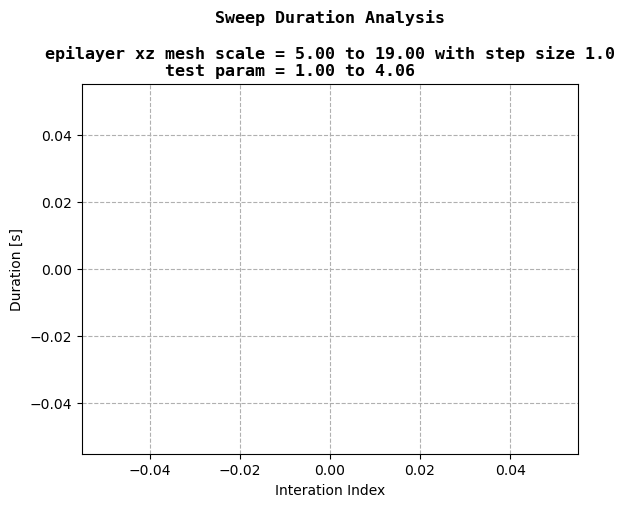

In [14]:
fig, ax =pfs.u_plot_scatter_with_error_bars(
    df_durations.index.tolist(),
    df_durations["Duration_Seconds"].tolist(),
    x_label="Interation Index",
    y_label="Duration [s]", 
    title=plot_title,
    fix_title_spacing=True,
    )
fig.savefig(fname=str(OUTPUT_FOLDER / "study_duration_analysis.png"), dpi=300, bbox_inches="tight")